In [ ]:
'''A simple Convolution Neural Network For Binary Classification of the Dog and Class Catagory using Keras'''

In [3]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense

In [4]:
classifier = Sequential()

'''First Convolution Layer'''
#32 = no of kernel and (3,3)=kernel size (64,64,3)= size of input to be provided where 3 means RGB 
classifier.add(Conv2D(32,(3,3),input_shape = (64,64,3),activation='relu'))
#Pooling means extract dominant features from the convoluted images,
#(2,2) pooling kernel used for  downsampling the spatial dimensions of the input
classifier.add(MaxPool2D(pool_size=(2,2)))


In [5]:
'''Second Convolution Layer'''
classifier.add(Conv2D(32,(3,3),activation='relu'))
classifier.add(MaxPool2D(pool_size=(2,2)))

In [6]:
'''Second Convolution Layer'''
classifier.add(Conv2D(32,(3,3),activation='relu'))
classifier.add(MaxPool2D(pool_size=(2,2)))

In [7]:
'''Flattening Layer'''
#Reduces n-dimension to 1-Dimension
classifier.add(Flatten())

In [8]:
''''''
#Densely Connected or Fully Connected layer to restrict no of features
#Input layer
classifier.add(Dense(units=256,activation='relu'))
#Hidden Layers
classifier.add(Dense(units=64,activation='relu'))
classifier.add(Dense(units=16,activation='relu'))
#Output Layer
classifier.add(Dense(units=1,activation='sigmoid'))

In [9]:
classifier.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 62, 62, 32)        896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 31, 31, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 29, 29, 32)        9248      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 12, 12, 32)        9248      
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 6, 6, 32)          0         
_________________________________________________________________
flatten (Flatten)            (None, 1152)              0

In [10]:
'''Compiler'''
# Adam optimizer best for Image Classification , it selects the best learning rate automatically, 
# Binary crossentropy used because here we hace only two class(Dog and Cat) 
# for Multiclass catagorical_crossentropy is used
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics='accuracy')

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.3,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)


In [12]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [13]:
training_set = train_datagen.flow_from_directory('/home/dipak/Desktop/AiProjects/dogandcat/training_set/training_set/',
                                                target_size= (64,64),
                                                batch_size=16,
                                                class_mode='binary')

Found 8005 images belonging to 2 classes.


In [14]:
test_set = test_datagen.flow_from_directory('/home/dipak/Desktop/AiProjects/dogandcat/test_set/test_set/',
                                                target_size= (64,64),
                                                batch_size=16,
                                                class_mode='binary')



Found 2023 images belonging to 2 classes.


# Fitting the Model or Training the Model

In [19]:
batch_size = 16
classifier.fit_generator(training_set,
                         steps_per_epoch = 8005//batch_size, #no of training image
                         epochs = 5,
                         validation_data = test_set,
                         validation_steps = 2023//batch_size #no of test image
                        )

Instructions for updating:
Please use Model.fit, which supports generators.
Epoch 1/5
500/500 [==============================] - 144s 289ms/step - loss: 0.6936 - accuracy: 0.5002 - val_loss: 0.6930 - val_accuracy: 0.5005
Epoch 2/5
500/500 [==============================] - 62s 123ms/step - loss: 0.6934 - accuracy: 0.5004 - val_loss: 0.6944 - val_accuracy: 0.4985
Epoch 3/5
500/500 [==============================] - 61s 123ms/step - loss: 0.6905 - accuracy: 0.5212 - val_loss: 0.6769 - val_accuracy: 0.5784
Epoch 4/5
500/500 [==============================] - 63s 125ms/step - loss: 0.6650 - accuracy: 0.5992 - val_loss: 0.6653 - val_accuracy: 0.6022
Epoch 5/5
500/500 [==============================] - 59s 118ms/step - loss: 0.6318 - accuracy: 0.6450 - val_loss: 0.6117 - val_accuracy: 0.6875


In [32]:
'''To save the trained Model'''
classifier.save('/home/dipak/Desktop/AiProjects/dogandcat/training_set/catvsdog.h5')

## Testing the Crafted Model

In [15]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
classifier = load_model('/home/dipak/Desktop/AiProjects/dogandcat/training_set/catvsdog.h5')
test_image = image.load_img('/home/dipak/Desktop/AiProjects/dogandcat/dog_nepal.jpg',target_size = (64,64))
test_array = np.expand_dims(test_image,axis = 0)
# print(test_array)

result = classifier.predict(test_array)

if result[0][0] == 1:
    prediction = 'dog'
    print(prediction)
else:
    prediction = 'cat'
    print(prediction)

dog


# Confusion Matrix

In [17]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix
labels = ['business', 'health']
batch_size = 16
y_pred = classifier.predict(test_set,2023//batch_size +1)
y_pred = np.argmax(y_pred,axis = 1)

reasult = confusion_matrix(test_set.classes,y_pred)
print(reasult)


[[1011    0]
 [1012    0]]


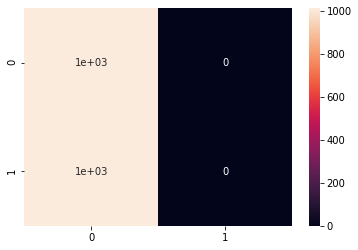

In [18]:
import seaborn as sns
sns.heatmap(reasult, annot=True)